In [1]:
# 데이터 읽기용 코드셀입니다.

import pandas as pd
print('='*20, 'game.xlsx 데이터 정보입니다.', '='*20)
tmp_df = pd.read_excel('game.xlsx', sheet_name='Sheet1')
display(tmp_df.shape)
display(tmp_df.columns)
display(tmp_df.head())

==================== game.xlsx 데이터 정보입니다. ====================


(2899, 9)

Index(['user_id', 'date', 'playtime', 'playcount', 'level', 'mainjob',
       'paycount', 'payamount', 'mainjoblevel'],
      dtype='object')

,user_id,date,playtime,playcount,level,mainjob,paycount,payamount,mainjoblevel
0,1001,2024-01-10,61,1.0,15,dealer,1,60300,60
1,1001,2024-01-11,14,1.0,15,dealer,1,100,60
2,1001,2024-01-12,16,1.0,15,tanker,1,151,60
3,1001,2024-01-13,1300,3.0,15,tanker,1,1000,60
4,1001,2024-01-14,41,3.0,15,tanker,1,16000,60


In [2]:
features = tmp_df[['playtime','playcount','level','paycount','payamount','mainjoblevel']]
print(features.shape)
display(features.head())

target = tmp_df['mainjob']
print(target.shape)
display(target.head())

(2899, 6)


,playtime,playcount,level,paycount,payamount,mainjoblevel
0,61,1.0,15,1,60300,60
1,14,1.0,15,1,100,60
2,16,1.0,15,1,151,60
3,1300,3.0,15,1,1000,60
4,41,3.0,15,1,16000,60


(2899,)


0    dealer
1    dealer
2    tanker
3    tanker
4    tanker
Name: mainjob, dtype: object

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)
#분할 이후 train 데이터 크기
print(X_train.shape)
print(y_train.shape)


#분할 이후 test 데이터 크기
print(X_test.shape)
print(y_test.shape)


#train 데이터와 test 데이터 비율 계산 결과
print(len(X_train) / len(tmp_df))
print(len(X_test) / len(tmp_df))

(2319, 6)
(2319,)
(580, 6)
(580,)
0.7999310106933425
0.20006898930665748


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

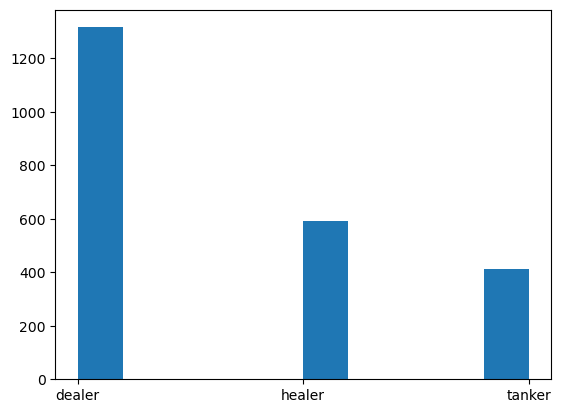

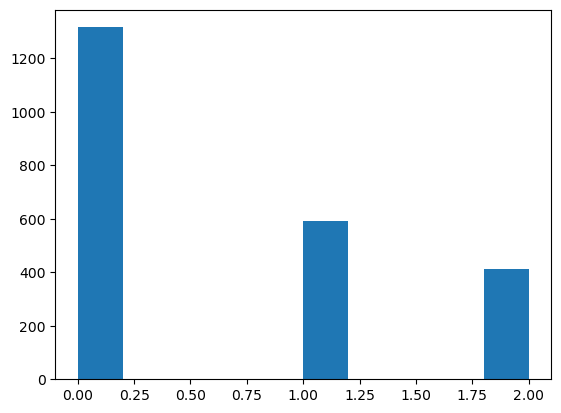

In [5]:
import matplotlib.pyplot as plt

# Label Encoding 이전 분포
plt.hist(y_train)
plt.show()

# Label Encoding 이후 분포
plt.hist(y_train_enc)
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


model = ExplainableBoostingClassifier(random_state=42)

model.fit(X_train, y_train_enc)

y_pred = model.predict(X_test)

#accuracy 결과
acc = accuracy_score(y_test_enc, y_pred)
print(acc)

#classification_report 결과
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

c:\Users\jongy\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:872: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(
c:\Users\jongy\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:1250: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(


0.9517241379310345
              precision    recall  f1-score   support

      dealer       0.95      0.97      0.96       320
      healer       0.97      0.96      0.96       137
      tanker       0.94      0.90      0.92       123

    accuracy                           0.95       580
   macro avg       0.95      0.94      0.95       580
weighted avg       0.95      0.95      0.95       580

